In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, glob, math, random, time
import numpy as np
import scipy.io as sio
import scipy.signal as sps
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt


DATA_DIR = "/content/drive/MyDrive/EMG"
OUT_DIR  = "/content/drive/MyDrive/EMG_runs/tinymyo_db5"

FS, N_CH = 200, 16
BAND, NOTCH = (20, 90), 50
WIN, STRIDE = 200, 50

TRAIN_REPS, VAL_REPS, TEST_REPS = [1, 3, 4, 6], [2], [5]


MOVES_PER_EX = {1: 12, 2: 17, 3: 23}
LABEL_OFFSET = {1: 0, 2: 12, 3: 29}
N_CLASSES = 53


PATCH, DIM, DEPTH, HEADS, DROPOUT = 20, 192, 8, 3, 0.1
BATCH, EPOCHS, WARMUP = 32, 50, 5
LR, MIN_LR, WD, LABEL_SMOOTH, CLIP = 5e-4, 1e-5, 0.01, 0.1, 1.0
PATIENCE = 7
BALANCE_LOSS = False
SEED = 0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
def get_var(mat, name):
    """Case-insensitive lookup ('emg' / 'Emg', 'restimulus' / 'Restimulus', ...)."""
    for k, v in mat.items():
        if k.lower() == name.lower():
            return v
    return None

def preprocess(emg):
    """Band-pass 20-90 Hz (4th order) + 50 Hz notch, zero-phase, per channel."""
    sos = sps.butter(4, BAND, btype="bandpass", fs=FS, output="sos")
    emg = sps.sosfiltfilt(sos, emg, axis=0)
    b, a = sps.iirnotch(NOTCH, Q=30, fs=FS)
    return sps.filtfilt(b, a, emg, axis=0)

def forward_fill_rep(rep):
    """Rest has repetition 0: carry the previous repetition id forward (leading rest -> 1)."""
    idx = np.where(rep > 0, np.arange(len(rep)), 0)
    np.maximum.accumulate(idx, out=idx)
    out = rep[idx].copy()
    out[out == 0] = 1
    return out

def make_windows(emg, lab, rep):
    """Sliding windows; label/repetition taken at the window centre."""
    rep = forward_fill_rep(rep)
    starts = np.arange(0, len(emg) - WIN + 1, STRIDE)
    keep = rep[starts] == rep[starts + WIN - 1]
    starts = starts[keep]
    centre = starts + WIN // 2
    X = np.stack([emg[s:s + WIN].T for s in starts])
    return X.astype(np.float32), lab[centre], rep[centre]

def load_file(path, ex):
    m = sio.loadmat(path)
    emg, lab = get_var(m, "emg"), get_var(m, "restimulus")
    rep = get_var(m, "rerepetition")
    if rep is None:
        rep = get_var(m, "repetition")
    if emg is None or lab is None or rep is None:
        raise KeyError(f"{path}: need emg, restimulus, (re)repetition; found {[k for k in m if not k.startswith('__')]}")
    emg = np.asarray(emg, dtype=np.float64)
    lab, rep = np.asarray(lab).ravel().astype(int), np.asarray(rep).ravel().astype(int)
    assert emg.shape[1] == N_CH and len(emg) == len(lab) == len(rep), f"{path}: unexpected shapes {emg.shape}"
    if lab.max() > MOVES_PER_EX[ex]:
        raise ValueError(f"{path}: label {lab.max()} > {MOVES_PER_EX[ex]} movements expected for E{ex}")
    lab = np.where(lab > 0, lab + LABEL_OFFSET[ex], 0)
    return make_windows(preprocess(emg).astype(np.float32), lab, rep)


files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.mat"), recursive=True))
pat = re.compile(r"S(\d+)_E(\d+)", re.I)
by_subject = {}
for f in files:
    m = pat.search(os.path.basename(f))
    if m:
        by_subject.setdefault(int(m.group(1)), []).append((int(m.group(2)), f))
print(f"{len(files)} .mat files, {len(by_subject)} subjects")
for s, items in sorted(by_subject.items()):
    if sorted(e for e, _ in items) != [1, 2, 3]:
        print(f"  WARNING subject {s}: exercises found = {sorted(e for e, _ in items)}")


parts = {k: ([], []) for k in ("train", "val", "test")}
for s, items in sorted(by_subject.items()):
    Xs, ys, rs = [], [], []
    for ex, f in sorted(items):
        X, y, r = load_file(f, ex)
        Xs.append(X); ys.append(y); rs.append(r)
    X, y, r = np.concatenate(Xs), np.concatenate(ys), np.concatenate(rs)
    tr = np.isin(r, TRAIN_REPS)
    mu = X[tr].mean(axis=(0, 2), keepdims=True)
    sd = X[tr].std(axis=(0, 2), keepdims=True) + 1e-8
    X = (X - mu) / sd
    for name, reps in (("train", TRAIN_REPS), ("val", VAL_REPS), ("test", TEST_REPS)):
        mask = np.isin(r, reps)
        parts[name][0].append(X[mask]); parts[name][1].append(y[mask])
    print(f"  subject {s}: {len(X)} windows")
    del Xs, X

Xtr, ytr = np.concatenate(parts["train"][0]), np.concatenate(parts["train"][1])
Xva, yva = np.concatenate(parts["val"][0]),   np.concatenate(parts["val"][1])
Xte, yte = np.concatenate(parts["test"][0]),  np.concatenate(parts["test"][1])
for n, X, y in (("train", Xtr, ytr), ("val", Xva, yva), ("test", Xte, yte)):
    print(f"{n:5s}: X {X.shape}  classes present {len(np.unique(y))}/{N_CLASSES}  rest fraction {np.mean(y == 0):.2f}")

30 .mat files, 10 subjects
  subject 1: 10131 windows
  subject 2: 11659 windows
  subject 3: 10277 windows
  subject 4: 11777 windows
  subject 5: 11796 windows
  subject 6: 11764 windows
  subject 7: 11848 windows
  subject 8: 11761 windows
  subject 9: 11758 windows
  subject 10: 11892 windows
train: X (77735, 16, 200)  classes present 53/53  rest fraction 0.64
val  : X (18211, 16, 200)  classes present 53/53  rest fraction 0.62
test : X (18717, 16, 200)  classes present 53/53  rest fraction 0.64


In [ ]:
def rope(x, cos, sin):
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1).flatten(-2)

class Block(nn.Module):
    def __init__(self, dim, heads, drop):
        super().__init__()
        self.h, self.drop = heads, drop
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.qkv, self.proj = nn.Linear(dim, 3 * dim), nn.Linear(dim, dim)
        self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Dropout(drop),
                                 nn.Linear(4 * dim, dim), nn.Dropout(drop))
    def forward(self, x, cos, sin):
        B, N, D = x.shape
        q, k, v = self.qkv(self.ln1(x)).reshape(B, N, 3, self.h, D // self.h).permute(2, 0, 3, 1, 4)
        q, k = rope(q, cos, sin), rope(k, cos, sin)
        a = F.scaled_dot_product_attention(q, k, v, dropout_p=self.drop if self.training else 0.0)
        x = x + self.proj(a.transpose(1, 2).reshape(B, N, D))
        return x + self.mlp(self.ln2(x))

class TinyMyoLike(nn.Module):
    def __init__(self, n_ch=N_CH, win=WIN, patch=PATCH, dim=DIM, depth=DEPTH, heads=HEADS,
                 n_cls=N_CLASSES, drop=DROPOUT):
        super().__init__()
        assert win % patch == 0 and (dim // heads) % 2 == 0
        self.n_ch, self.n_p, self.patch = n_ch, win // patch, patch
        self.embed = nn.Linear(patch, dim)
        self.ch_embed = nn.Embedding(n_ch, dim)
        self.blocks = nn.ModuleList([Block(dim, heads, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(n_ch * dim, n_cls)

        hd = dim // heads
        pos = torch.arange(self.n_p).repeat(n_ch).float()
        ang = pos[:, None] * (1.0 / 10000 ** (torch.arange(0, hd, 2).float() / hd))[None]
        self.register_buffer("cos", ang.cos(), persistent=False)
        self.register_buffer("sin", ang.sin(), persistent=False)
    def forward(self, x):
        B = x.shape[0]
        t = self.embed(x.reshape(B, self.n_ch, self.n_p, self.patch))
        t = t + self.ch_embed.weight[None, :, None, :]
        t = t.flatten(1, 2)
        for blk in self.blocks:
            t = blk(t, self.cos.to(t.dtype), self.sin.to(t.dtype))
        t = self.norm(t).reshape(B, self.n_ch, self.n_p, -1).mean(2)
        return self.head(t.flatten(1))

model = TinyMyoLike().to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

parameters: 3.73 M


In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
CKPT = os.path.join(OUT_DIR, "best_tinymyo_db5.pt")

Xtr_t, ytr_t = torch.from_numpy(Xtr), torch.from_numpy(ytr).long()
Xva_t, yva_t = torch.from_numpy(Xva), torch.from_numpy(yva).long()
Xte_t, yte_t = torch.from_numpy(Xte), torch.from_numpy(yte).long()

use_amp = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
opt = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.98), weight_decay=WD)

weight = None
if BALANCE_LOSS:
    cnt = torch.bincount(ytr_t, minlength=N_CLASSES).float().clamp(min=1)
    weight = ((cnt.sum() / (N_CLASSES * cnt)) ** 0.5).to(device)
criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=LABEL_SMOOTH)

def lr_at(ep):
    if ep < WARMUP:
        return LR * (ep + 1) / WARMUP
    t = (ep - WARMUP) / max(1, EPOCHS - WARMUP)
    return MIN_LR + 0.5 * (LR - MIN_LR) * (1 + math.cos(math.pi * t))

@torch.no_grad()
def predict(X, bs=256):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            out.append(model(X[i:i + bs].to(device)).argmax(1).cpu())
    return torch.cat(out).numpy()

best_f1, bad_epochs = -1.0, 0
for ep in range(EPOCHS):
    for g in opt.param_groups:
        g["lr"] = lr_at(ep)
    model.train(); t0 = time.time(); loss_sum = 0.0
    perm = torch.randperm(len(Xtr_t))
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i + BATCH]
        xb, yb = Xtr_t[idx].to(device), ytr_t[idx].to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            loss = criterion(model(xb), yb)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        scaler.step(opt); scaler.update()
        loss_sum += loss.item() * len(idx)
    pv = predict(Xva_t)
    acc, f1 = accuracy_score(yva, pv), f1_score(yva, pv, average="macro")
    flag = ""
    if f1 > best_f1:
        best_f1, bad_epochs = f1, 0
        torch.save({"model": model.state_dict(), "epoch": ep, "val_macro_f1": f1}, CKPT)
        flag = "  <- saved"
    else:
        bad_epochs += 1
    print(f"ep {ep + 1:02d} | loss {loss_sum / len(perm):.4f} | val acc {acc:.4f} | val macro-F1 {f1:.4f} | {time.time() - t0:.0f}s{flag}")
    if bad_epochs >= PATIENCE:
        print("early stopping"); break

ep 01 | loss 1.6523 | val acc 0.7330 | val macro-F1 0.3345 | 92s  <- saved
ep 02 | loss 1.4143 | val acc 0.7642 | val macro-F1 0.4325 | 92s  <- saved
ep 03 | loss 1.2834 | val acc 0.7923 | val macro-F1 0.5053 | 92s  <- saved
ep 04 | loss 1.1927 | val acc 0.8045 | val macro-F1 0.5332 | 92s  <- saved
ep 05 | loss 1.1356 | val acc 0.8102 | val macro-F1 0.5531 | 92s  <- saved
ep 06 | loss 1.0591 | val acc 0.8235 | val macro-F1 0.5823 | 92s  <- saved
ep 07 | loss 0.9962 | val acc 0.8271 | val macro-F1 0.5921 | 92s  <- saved
ep 08 | loss 0.9435 | val acc 0.8359 | val macro-F1 0.6232 | 92s  <- saved
ep 09 | loss 0.9009 | val acc 0.8402 | val macro-F1 0.6261 | 92s  <- saved
ep 10 | loss 0.8665 | val acc 0.8356 | val macro-F1 0.6167 | 92s
ep 11 | loss 0.8417 | val acc 0.8432 | val macro-F1 0.6316 | 92s  <- saved
ep 12 | loss 0.8221 | val acc 0.8429 | val macro-F1 0.6296 | 92s
ep 13 | loss 0.8054 | val acc 0.8417 | val macro-F1 0.6242 | 92s
ep 14 | loss 0.7926 | val acc 0.8372 | val macro-F1 0.6

loaded epoch 50 (val macro-F1 0.7300)

TEST  Accuracy: 0.8969 | Macro-F1: 0.7504 | Balanced acc: 0.7311
              precision    recall  f1-score   support

        rest      0.960     0.995     0.977     11888
       E1_M1      0.813     0.731     0.770       167
       E1_M2      0.810     0.860     0.834       114
       E1_M3      0.826     0.778     0.801       153
       E1_M4      0.860     0.844     0.852       109
       E1_M5      0.840     0.809     0.824       136
       E1_M6      0.923     0.771     0.840       140
       E1_M7      0.823     0.718     0.767       149
       E1_M8      0.900     0.755     0.821       143
       E1_M9      0.674     0.608     0.639       102
      E1_M10      0.793     0.546     0.647       119
      E1_M11      0.622     0.848     0.718        99
      E1_M12      0.800     0.689     0.740       122
       E2_M1      0.877     0.690     0.773       155
       E2_M2      0.949     0.917     0.933       121
       E2_M3      0.857     0.9

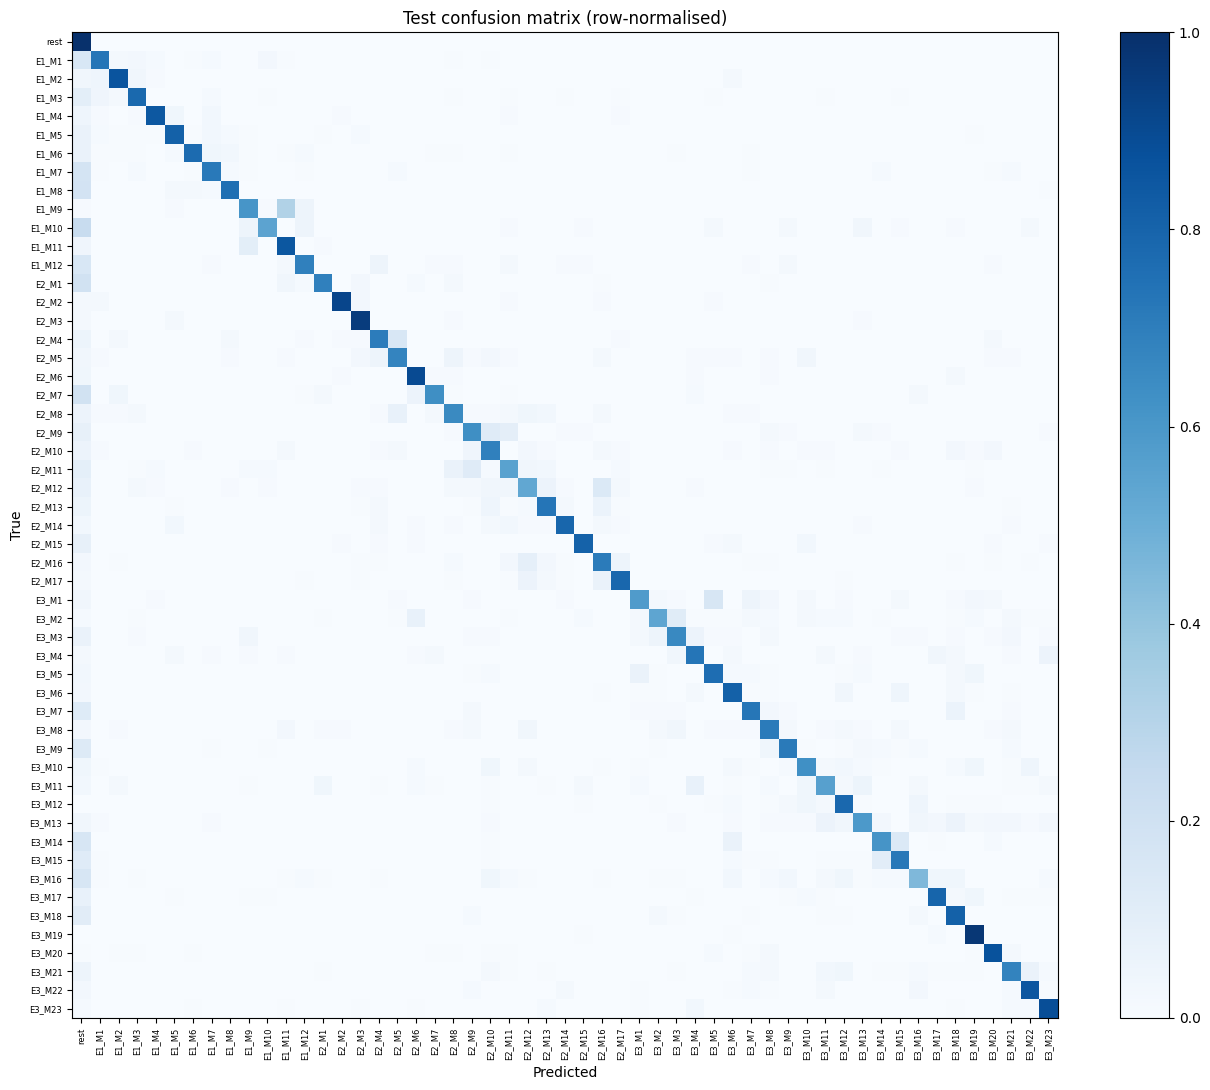

In [ ]:
ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"loaded epoch {ckpt['epoch'] + 1} (val macro-F1 {ckpt['val_macro_f1']:.4f})")

pt = predict(Xte_t)
print(f"\nTEST  Accuracy: {accuracy_score(yte, pt):.4f} | Macro-F1: {f1_score(yte, pt, average='macro'):.4f} "
      f"| Balanced acc: {balanced_accuracy_score(yte, pt):.4f}")

names = ["rest"]
for ex, n in MOVES_PER_EX.items():
    names += [f"E{ex}_M{i}" for i in range(1, n + 1)]
labels = list(range(N_CLASSES))
print(classification_report(yte, pt, labels=labels, target_names=names, zero_division=0, digits=3))

cm = confusion_matrix(yte, pt, labels=labels)
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(labels); ax.set_xticklabels(names, rotation=90, fontsize=6)
ax.set_yticks(labels); ax.set_yticklabels(names, fontsize=6)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test confusion matrix (row-normalised)")
fig.colorbar(im, fraction=0.046); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_test.png"), dpi=150)
plt.show()